# Pipeline completo - Base 05
Responsavel: Giovanna Pereira da Rosa Nascimento

Executar toda a analise e os quatro modelos neste notebook.

In [1]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_ID = 'base_05'
RESPONSAVEL = 'Giovanna'
DATA_PATH = Path('../data/raw/base_05/gold.daily.prices.csv')
TARGET = 'VALUE'
DATETIME_COL = 'DATE'
SOURCE = 'dengyishuo/quantitative-finance, gold.daily.prices.csv'
SOURCE_URL = 'https://github.com/dengyishuo/quantitative-finance'
TARGET_DESCRIPTION = 'Cotacao diaria do ouro, agregada pela media semanal.'
TARGET_UNIT = 'USD por onca troy'
RAW_FREQUENCY = 'diaria (dias de negociacao)'
FREQ = 'W-SUN'
HORIZON = 1
SEASONAL_PERIOD = 52
TRAIN_RATIO = 0.75
TUNING_SPLITS = 3
TUNING_VALIDATION_SIZE = 52
RANDOM_STATE = 42

print(f'Base: {BASE_ID} | Frequencia modelada: {FREQ} | Horizonte: {HORIZON} semana')

Base: base_05 | Frequencia modelada: W-SUN | Horizonte: 1 semana


## 1. Documentacao e auditoria


In [2]:
# Leitura e validacao do esquema original, que contem somente data e cotacao-alvo
df = pd.read_csv(DATA_PATH, sep=r'\s+', na_values='.')
if DATETIME_COL not in df.columns or TARGET not in df.columns:
    raise ValueError(f'Esperadas as colunas {DATETIME_COL!r} e {TARGET!r}; recebidas: {df.columns.tolist()}')

df[DATETIME_COL] = pd.to_datetime(df[DATETIME_COL], errors='coerce')
datas_invalidas = int(df[DATETIME_COL].isna().sum())
if datas_invalidas:
    raise ValueError(f'{datas_invalidas} linhas possuem datas invalidas.')

df = df.set_index(DATETIME_COL).sort_index()
print(f'Fonte: {SOURCE} ({SOURCE_URL})')
print(f'Colunas carregadas: {df.columns.tolist()}')

Fonte: dengyishuo/quantitative-finance, gold.daily.prices.csv (https://github.com/dengyishuo/quantitative-finance)
Colunas carregadas: ['VALUE']


In [3]:
import pandas as pd

# Contar quantas vezes cada dia da semana aparece no índice (0=Segunda, 1=Terça, ..., 6=Domingo)
dias_semana = df.index.dayofweek.value_counts().sort_index()

print("Distribuição dos dias da semana na base original:")
print(dias_semana)

Distribuição dos dias da semana na base original:
DATE
0    2402
1    2402
2    2402
3    2402
4    2401
Name: count, dtype: int64


=== DOCUMENTACAO E AUDITORIA ===
Fonte: dengyishuo/quantitative-finance, gold.daily.prices.csv | https://github.com/dengyishuo/quantitative-finance
Descricao: Cotacao diaria do ouro, agregada pela media semanal.
Alvo/unidade: VALUE (USD por onca troy)
Periodo bruto: 1968-04-01 a 2014-04-10
Frequencia bruta: diaria (dias de negociacao); frequencia modelada: W-SUN
Registros: 12009 | duplicidades: 0 | nulos no alvo: 368
Intervalos entre datas > 3 dias: 0 (incluem fins de semana/feriados; revisar lacunas > 7 dias: 0)
Valores sinalizados pelo criterio IQR: 1664; mantidos por representarem possiveis movimentos reais do ouro.
count    11641.000000
mean       446.189980
std        382.405742
min         34.775000
25%        260.900000
50%        363.750000
75%        444.500000
max       1896.500000
Name: VALUE, dtype: float64

Dicionario de variaveis:


,variavel,papel,descricao,unidade
0,DATE,indice temporal,Data da cotacao original,data
1,VALUE,alvo,"Cotacao diaria do ouro, agregada pela media se...",USD por onca troy


Variaveis externas fornecidas pelo arquivo: nenhuma; o CSV contem apenas DATE e VALUE.
Agregacao semanal por media; semanas sem cotacao preenchidas com forward-fill: 0.
Registros semanais: 2402 | nulos apos limpeza: 0
Valores extremos foram sinalizados para inspecao, sem remocao automatica.


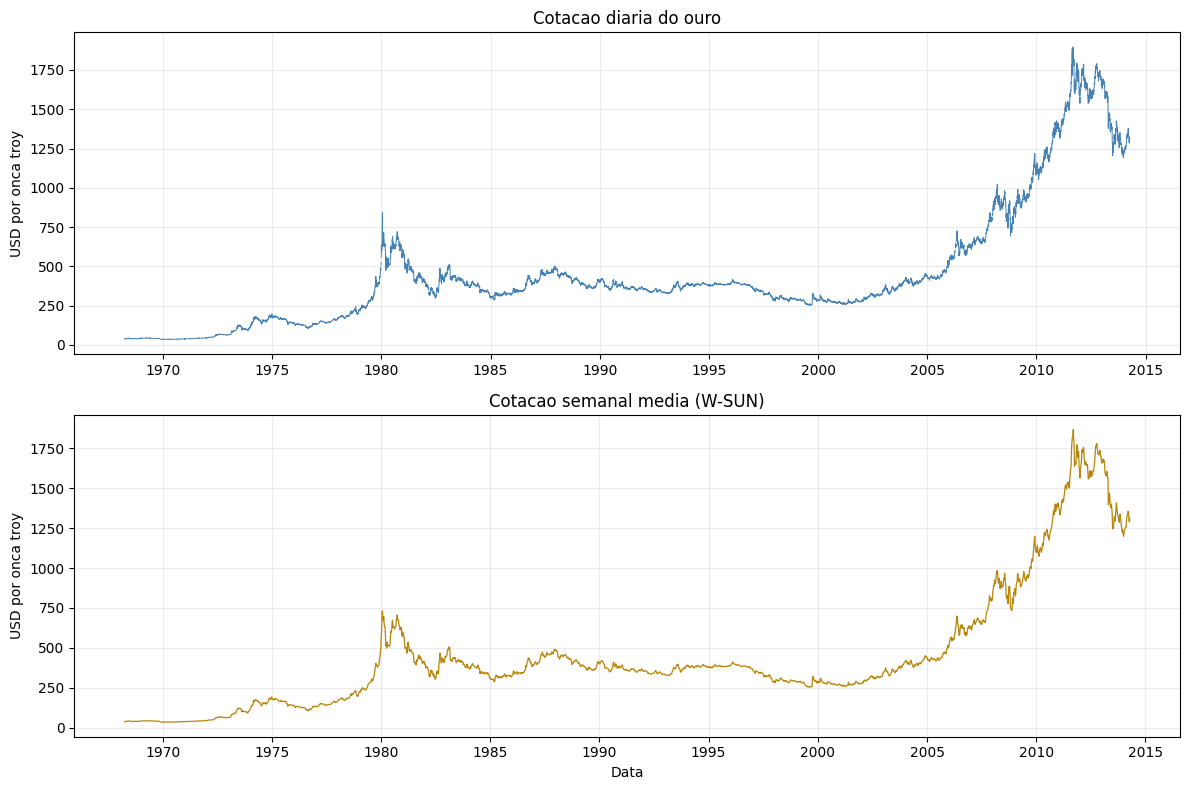

In [4]:
# Auditoria temporal, dados ausentes e valores extremos
n_duplicados = int(df.index.duplicated().sum())
nulos_originais = int(df[TARGET].isna().sum())
periodo_inicio, periodo_fim = df.index.min(), df.index.max()
diferencas_dias = df.index.to_series().diff().dt.days.dropna()

q1, q3 = df[TARGET].quantile([0.25, 0.75])
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr
mascara_outliers = (df[TARGET] < limite_inferior) | (df[TARGET] > limite_superior)

print('=== DOCUMENTACAO E AUDITORIA ===')
print(f'Fonte: {SOURCE} | {SOURCE_URL}')
print(f'Descricao: {TARGET_DESCRIPTION}')
print(f'Alvo/unidade: {TARGET} ({TARGET_UNIT})')
print(f'Periodo bruto: {periodo_inicio:%Y-%m-%d} a {periodo_fim:%Y-%m-%d}')
print(f'Frequencia bruta: {RAW_FREQUENCY}; frequencia modelada: {FREQ}')
print(f'Registros: {len(df)} | duplicidades: {n_duplicados} | nulos no alvo: {nulos_originais}')
print(f'Intervalos entre datas > 3 dias: {(diferencas_dias > 3).sum()} (incluem fins de semana/feriados; revisar lacunas > 7 dias: {(diferencas_dias > 7).sum()})')
print(f'Valores sinalizados pelo criterio IQR: {int(mascara_outliers.sum())}; mantidos por representarem possiveis movimentos reais do ouro.')
print(df[TARGET].describe())

dicionario_variaveis = pd.DataFrame([
    {'variavel': DATETIME_COL, 'papel': 'indice temporal', 'descricao': 'Data da cotacao original', 'unidade': 'data'},
    {'variavel': TARGET, 'papel': 'alvo', 'descricao': TARGET_DESCRIPTION, 'unidade': TARGET_UNIT},
])
print('\nDicionario de variaveis:')
display(dicionario_variaveis)
print('Variaveis externas fornecidas pelo arquivo: nenhuma; o CSV contem apenas DATE e VALUE.')

# Duplicatas de uma mesma data sao consolidadas pela media; semanas sem cotacao usam apenas o ultimo valor conhecido.
df = df.groupby(level=0).mean(numeric_only=True).sort_index()
df_regular = df.resample(FREQ).mean()
semanas_sem_cotacao = int(df_regular[TARGET].isna().sum())
df_clean = df_regular.copy()
df_clean[TARGET] = df_clean[TARGET].ffill()
df_clean = df_clean.rename(columns={TARGET: 'alvo'})
if df_clean['alvo'].isna().any():
    raise ValueError('Ha semanas iniciais sem valor que nao podem ser preenchidas sem usar informacao futura.')
print(f'Agregacao semanal por media; semanas sem cotacao preenchidas com forward-fill: {semanas_sem_cotacao}.')
print(f'Registros semanais: {len(df_clean)} | nulos apos limpeza: {int(df_clean.alvo.isna().sum())}')
print('Valores extremos foram sinalizados para inspecao, sem remocao automatica.')

# Graficos da serie-alvo; nao ha variaveis externas neste conjunto.
FIGURES_DIR = Path('../results/figures/base_05')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(df.index, df[TARGET], linewidth=0.7, color='steelblue')
axes[0].set(title='Cotacao diaria do ouro', ylabel=TARGET_UNIT)
axes[1].plot(df_clean.index, df_clean['alvo'], linewidth=0.9, color='darkgoldenrod')
axes[1].set(title='Cotacao semanal media (W-SUN)', ylabel=TARGET_UNIT, xlabel='Data')
for ax in axes:
    ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'base_05_serie_alvo.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Limpeza, EDA e STL

In [5]:
import numpy as np
from statsmodels.tsa.seasonal import STL

# Como 'df_clean' e a coluna 'alvo' já existem na memória, aplicamos o STL direto:
stl = STL(df_clean['alvo'], period=52, robust=True)
res_stl = stl.fit()

# Adicionar os componentes ao DataFrame existente
df_clean['tendencia'] = res_stl.trend
df_clean['sazonalidade'] = res_stl.seasonal
df_clean['residuo_stl'] = res_stl.resid

# Cálculo da Força da Sazonalidade
var_res = np.var(df_clean['residuo_stl'])
var_saz_res = np.var(df_clean['sazonalidade'] + df_clean['residuo_stl'])
forca_sazonalidade = max(0, 1 - (var_res / var_saz_res))

print(f"Decomposição STL executada com sucesso!")
print(f"Força da Sazonalidade: {forca_sazonalidade:.4f}")

Decomposição STL executada com sucesso!
Força da Sazonalidade: 0.0000


## 3. Feature engineering sem vazamento


In [6]:
def criar_features(data):
    df_feat = data[['alvo']].copy()

    # Todas as features do alvo usam apenas observacoes anteriores; horizonte = 1 semana.
    for lag in [1, 2, 4, 8, SEASONAL_PERIOD]:
        df_feat[f'alvo_lag_{lag}'] = df_feat['alvo'].shift(lag)

    for janela in [4, 12]:
        serie_passada = df_feat['alvo'].shift(1)
        df_feat[f'media_movel_{janela}'] = serie_passada.rolling(janela).mean()
        df_feat[f'std_movel_{janela}'] = serie_passada.rolling(janela).std()

    mes = data.index.month
    semana = data.index.isocalendar().week.astype(int).to_numpy()
    df_feat['mes_sen'] = np.sin(2 * np.pi * mes / 12)
    df_feat['mes_cos'] = np.cos(2 * np.pi * mes / 12)
    df_feat['semana_sen'] = np.sin(2 * np.pi * semana / SEASONAL_PERIOD)
    df_feat['semana_cos'] = np.cos(2 * np.pi * semana / SEASONAL_PERIOD)

    n_antes = len(df_feat)
    df_feat = df_feat.dropna()
    print(f'Linhas descartadas por lags/janelas sem historico: {n_antes - len(df_feat)} de {n_antes}.')
    return df_feat

df_modelagem = criar_features(df_clean)
FEATURE_COLUMNS = [col for col in df_modelagem.columns if col != 'alvo']
print(f'Features compartilhadas por RF e SVR ({len(FEATURE_COLUMNS)}): {FEATURE_COLUMNS}')
print(f'Dimensoes da base de modelagem: {df_modelagem.shape}; horizonte: {HORIZON} semana.')

Linhas descartadas por lags/janelas sem historico: 52 de 2402.
Features compartilhadas por RF e SVR (13): ['alvo_lag_1', 'alvo_lag_2', 'alvo_lag_4', 'alvo_lag_8', 'alvo_lag_52', 'media_movel_4', 'std_movel_4', 'media_movel_12', 'std_movel_12', 'mes_sen', 'mes_cos', 'semana_sen', 'semana_cos']
Dimensoes da base de modelagem: (2350, 14); horizonte: 1 semana.


## 4. Walk-forward e otimizacao

In [7]:
# Corte cronologico 75/25; o trecho final fica isolado ate a avaliacao walk-forward.
train_size = int(len(df_modelagem) * TRAIN_RATIO)
X = df_modelagem[FEATURE_COLUMNS].copy()
y = df_modelagem['alvo'].copy()
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f'Treino: {len(X_train)} ({X_train.index.min():%Y-%m-%d} a {X_train.index.max():%Y-%m-%d})')
print(f'Teste final: {len(X_test)} ({X_test.index.min():%Y-%m-%d} a {X_test.index.max():%Y-%m-%d})')
print(f'Datas de previsao compartilhadas; horizonte = {HORIZON} semana.')

Treino: 1762 (1969-04-06 a 2003-01-05)
Teste final: 588 (2003-01-12 a 2014-04-13)
Datas de previsao compartilhadas; horizonte = 1 semana.


In [16]:
def walk_forward_statsmodels(fitted_model, actuals, model_name):
    """Preve um periodo por origem e incorpora o observado sem reajustar parametros."""
    if model_name != 'SARIMAX':
        raise ValueError(f'Modelo state-space nao suportado: {model_name}')

    current_fit = fitted_model
    predictions = []
    for timestamp, actual in actuals.items():
        forecast = current_fit.get_forecast(steps=HORIZON).predicted_mean
        predictions.append(float(np.asarray(forecast).reshape(-1)[0]))
        observed = pd.Series([float(actual)], index=pd.DatetimeIndex([timestamp]), name=actuals.name)
        current_fit = current_fit.extend(observed)
    return np.asarray(predictions), current_fit

print('Walk-forward SARIMAX pronto: previsao de 1 semana e atualizacao incremental, sem reajuste de parametros.')

Walk-forward SARIMAX pronto: previsao de 1 semana e atualizacao incremental, sem reajuste de parametros.


## 5. SARIMAX

In [17]:
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

# Nao ha variaveis externas no arquivo; SARIMAX e ajustado somente ao alvo.
time_series_cv = TimeSeriesSplit(n_splits=TUNING_SPLITS, test_size=TUNING_VALIDATION_SIZE)
cv_splits = list(time_series_cv.split(X_train))
sarimax_candidates = [
    {'order': (0, 1, 1), 'seasonal_order': (0, 1, 1, SEASONAL_PERIOD)},
    {'order': (1, 1, 0), 'seasonal_order': (0, 1, 1, SEASONAL_PERIOD)},
    {'order': (1, 0, 1), 'seasonal_order': (1, 0, 0, SEASONAL_PERIOD)},
    {'order': (1, 1, 1), 'seasonal_order': (1, 0, 1, SEASONAL_PERIOD)},
]

resultados_sarimax_cv = []
t0 = time.perf_counter()
for candidate in sarimax_candidates:
    fold_mae, fold_aic, fold_bic = [], [], []
    for train_idx, valid_idx in cv_splits:
        y_fold_train = y_train.iloc[train_idx]
        y_fold_valid = y_train.iloc[valid_idx]
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            fitted = SARIMAX(
                y_fold_train,
                order=candidate['order'],
                seasonal_order=candidate['seasonal_order'],
                enforce_stationarity=False,
                enforce_invertibility=False,
            ).fit(disp=False, maxiter=50)
        fold_pred, _ = walk_forward_statsmodels(fitted, y_fold_valid, 'SARIMAX')
        fold_mae.append(mean_absolute_error(y_fold_valid, fold_pred))
        fold_aic.append(fitted.aic)
        fold_bic.append(fitted.bic)
    resultados_sarimax_cv.append({
        **candidate,
        'mae_cv': float(np.mean(fold_mae)),
        'aic_cv_medio': float(np.mean(fold_aic)),
        'bic_cv_medio': float(np.mean(fold_bic)),
    })

sarimax_tuning_seconds = time.perf_counter() - t0
df_sarimax_cv = pd.DataFrame(resultados_sarimax_cv).sort_values(['mae_cv', 'bic_cv_medio'])
melhor_sarimax = df_sarimax_cv.iloc[0]
SARIMAX_PARAMS = {
    'order': melhor_sarimax['order'],
    'seasonal_order': melhor_sarimax['seasonal_order'],
}
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    sarimax_model = SARIMAX(
        y_train,
        order=SARIMAX_PARAMS['order'],
        seasonal_order=SARIMAX_PARAMS['seasonal_order'],
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False, maxiter=50)

print('=== SARIMAX: busca somente no treino ===')
print(df_sarimax_cv.to_string(index=False))
print(f'Melhores parametros: {SARIMAX_PARAMS}; AIC={sarimax_model.aic:.2f}; BIC={sarimax_model.bic:.2f}')
print(f'MAE CV={melhor_sarimax.mae_cv:.4f}; tempo de busca={sarimax_tuning_seconds:.2f}s')

=== SARIMAX: busca somente no treino ===
    order seasonal_order   mae_cv  aic_cv_medio  bic_cv_medio
(0, 1, 1)  (0, 1, 1, 52) 3.191185  11296.186278  11312.225119
(1, 0, 1)  (1, 0, 0, 52) 3.215889  11535.908940  11557.431055
(1, 1, 0)  (0, 1, 1, 52) 3.226227  11298.955718  11314.996494
(1, 1, 1)  (1, 0, 1, 52) 3.301544  11518.545193  11545.441599
Melhores parametros: {'order': (0, 1, 1), 'seasonal_order': (0, 1, 1, 52)}; AIC=11970.56; BIC=11986.79
MAE CV=3.1912; tempo de busca=26894.99s


## 6. Holt-Winters

In [18]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Ajuste aditivo no treino; os parametros de suavizacao permanecem fixos durante o teste.
hw_model = ExponentialSmoothing(
    y_train,
    trend='add',
    seasonal='add',
    seasonal_periods=SEASONAL_PERIOD,
).fit()

hw_parameters = hw_model.params
hw_alpha = float(hw_parameters['smoothing_level'])
hw_beta = float(hw_parameters['smoothing_trend'])
hw_gamma = float(hw_parameters['smoothing_seasonal'])
hw_level = float(hw_model.level.iloc[-1])
hw_trend = float(hw_model.trend.iloc[-1])
hw_seasonal = hw_model.season.iloc[-SEASONAL_PERIOD:].to_numpy(dtype=float).tolist()
hw_predictions = []

for actual in y_test:
    seasonal_component = hw_seasonal[0]
    hw_predictions.append(hw_level + hw_trend + seasonal_component)

    updated_level = hw_alpha * (float(actual) - seasonal_component) + (1 - hw_alpha) * (hw_level + hw_trend)
    updated_trend = hw_beta * (updated_level - hw_level) + (1 - hw_beta) * hw_trend
    updated_seasonal = hw_gamma * (float(actual) - updated_level) + (1 - hw_gamma) * seasonal_component

    hw_level, hw_trend = updated_level, updated_trend
    hw_seasonal = hw_seasonal[1:] + [updated_seasonal]

hw_pred = pd.Series(hw_predictions, index=y_test.index, name='Holt-Winters')
mae_hw = mean_absolute_error(y_test, hw_pred)

print('\n=== HOLT-WINTERS WALK-FORWARD ===')
print(f'Parametros: trend=add, seasonal=add, m={SEASONAL_PERIOD}')
print(f'Suavizacao: alpha={hw_alpha:.4f}, beta={hw_beta:.4f}, gamma={hw_gamma:.4f}')
print(f'MAE no conjunto de teste: {mae_hw:.4f}')


=== HOLT-WINTERS WALK-FORWARD ===
Parametros: trend=add, seasonal=add, m=52
Suavizacao: alpha=1.0000, beta=0.0000, gamma=0.0000
MAE no conjunto de teste: 15.9903


C:\Users\giovannarosa-ieg\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


## 7. Random Forest

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Busca de hiperparâmetros com validação cruzada temporal no conjunto de treino
time_series_cv = TimeSeriesSplit(n_splits=3)
rf_parameters = {
    'max_depth': [8, None],
    'min_samples_leaf': [1, 3],
    'max_features': ['sqrt', 0.8],
}
rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    param_grid=rf_parameters,
    scoring='neg_mean_absolute_error',
    cv=time_series_cv,
    n_jobs=1,
)
rf_grid.fit(X_train, y_train)
rf_model = rf_grid.best_estimator_
rf_pred = rf_model.predict(X_test)
mae_rf = mean_absolute_error(y_test, rf_pred)

print("\n=== RANDOM FOREST OTIMIZADO ===")
print(f"Melhores parâmetros: {rf_grid.best_params_}")
print(f"MAE médio na validação cruzada: {-rf_grid.best_score_:.4f}")
print(f"MAE no conjunto de teste: {mae_rf:.4f}")


=== RANDOM FOREST OTIMIZADO ===
Melhores parâmetros: {'max_depth': 8, 'max_features': 0.8, 'min_samples_leaf': 3}
MAE médio na validação cruzada: 69.8443
MAE no conjunto de teste: 364.9088


## 8. SVR

In [20]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# O scaler é ajustado dentro de cada fold para evitar vazamento de informação
svr_model = make_pipeline(
    StandardScaler(),
    SVR(kernel='rbf'),
)
svr_parameters = {
    'svr__C': [1, 10, 100],
    'svr__epsilon': [0.05, 0.20],
    'svr__gamma': ['scale', 0.01],
}
svr_grid = GridSearchCV(
    estimator=svr_model,
    param_grid=svr_parameters,
    scoring='neg_mean_absolute_error',
    cv=time_series_cv,
    n_jobs=1,
)
svr_grid.fit(X_train, y_train)
svr_model = svr_grid.best_estimator_
svr_pred = svr_model.predict(X_test)
mae_svr = mean_absolute_error(y_test, svr_pred)

print("\n=== SVR OTIMIZADO ===")
print(f"Melhores parâmetros: {svr_grid.best_params_}")
print(f"MAE médio na validação cruzada: {-svr_grid.best_score_:.4f}")
print(f"MAE no conjunto de teste: {mae_svr:.4f}")

# Seleciona o modelo pela validação cruzada; o teste fica reservado para avaliação final
if rf_grid.best_score_ >= svr_grid.best_score_:
    modelo_final = rf_model
    y_pred = rf_pred
    nome_modelo_final = 'Random Forest'
else:
    modelo_final = svr_model
    y_pred = svr_pred
    nome_modelo_final = 'SVR'

print(f"\nModelo selecionado pela validação cruzada: {nome_modelo_final}")


=== SVR OTIMIZADO ===
Melhores parâmetros: {'svr__C': 100, 'svr__epsilon': 0.2, 'svr__gamma': 0.01}
MAE médio na validação cruzada: 75.5848
MAE no conjunto de teste: 427.0910

Modelo selecionado pela validação cruzada: Random Forest


## 9. MAE, residuos, ACF e Ljung-Box

MAE Final: 364.9088
Média dos Resíduos: 362.6720
Desvio Padrão dos Resíduos: 385.5845


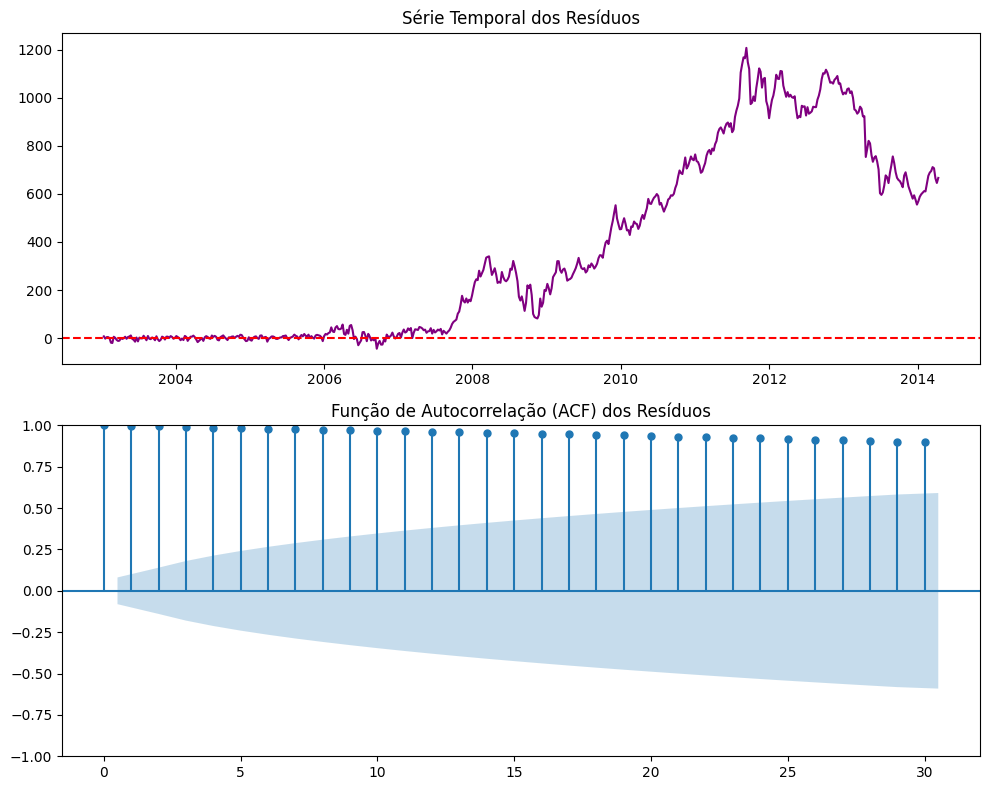


=== TESTE DE LJUNG-BOX ===
         lb_stat  lb_pvalue
10   5736.080700        0.0
20  11203.881863        0.0


In [21]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

# Exemplo considerando que você guardou as previsões do seu melhor modelo em 'y_pred'
# resíduos = valor real - valor previsto
residuos = y_test - y_pred

# 1. MAE e Estatísticas Básicas do Erro
mae_final = mean_absolute_error(y_test, y_pred)
print(f"MAE Final: {mae_final:.4f}")
print(f"Média dos Resíduos: {residuos.mean():.4f}")
print(f"Desvio Padrão dos Resíduos: {residuos.std():.4f}")

# 2. Gráfico dos Resíduos e ACF
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Plot da série de resíduos ao longo do tempo
axes[0].plot(residuos.index, residuos, color='purple')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Série Temporal dos Resíduos')

# Plot da Autocorrelação (ACF) dos resíduos
plot_acf(residuos.dropna(), ax=axes[1], lags=30)
axes[1].set_title('Função de Autocorrelação (ACF) dos Resíduos')

plt.tight_layout()
plt.show()

# 3. Teste de Ljung-Box (verifica se há autocorrelação significativa nos resíduos)
# p-valor > 0.05 indica que os resíduos são ruído branco (desejado)
lb_test = acorr_ljungbox(residuos.dropna(), lags=[10, 20], return_df=True)
print("\n=== TESTE DE LJUNG-BOX ===")
print(lb_test)

## 10. Importancia e exportacao


=== TOP 10 FEATURES - RANDOM FOREST (IMPURITY) ===
       Feature  Importancia  Desvio_Padrao   Metodo
    alvo_lag_1     0.491250            0.0 impurity
    alvo_lag_2     0.276405            0.0 impurity
 media_movel_4     0.123061            0.0 impurity
media_movel_12     0.081934            0.0 impurity
    alvo_lag_4     0.023888            0.0 impurity
   alvo_lag_52     0.001735            0.0 impurity
    alvo_lag_8     0.000562            0.0 impurity
    semana_sen     0.000389            0.0 impurity
  std_movel_12     0.000238            0.0 impurity
   std_movel_4     0.000237            0.0 impurity

=== TOP 10 FEATURES - SVR (PERMUTATION IMPORTANCE) ===
       Feature  Importancia  Desvio_Padrao          Metodo
    alvo_lag_1    65.066342       0.382800 permutation_mae
 media_movel_4    23.099073       0.509805 permutation_mae
    alvo_lag_2    23.009872       0.488231 permutation_mae
media_movel_12    11.311633       0.613819 permutation_mae
    alvo_lag_8     7.0143

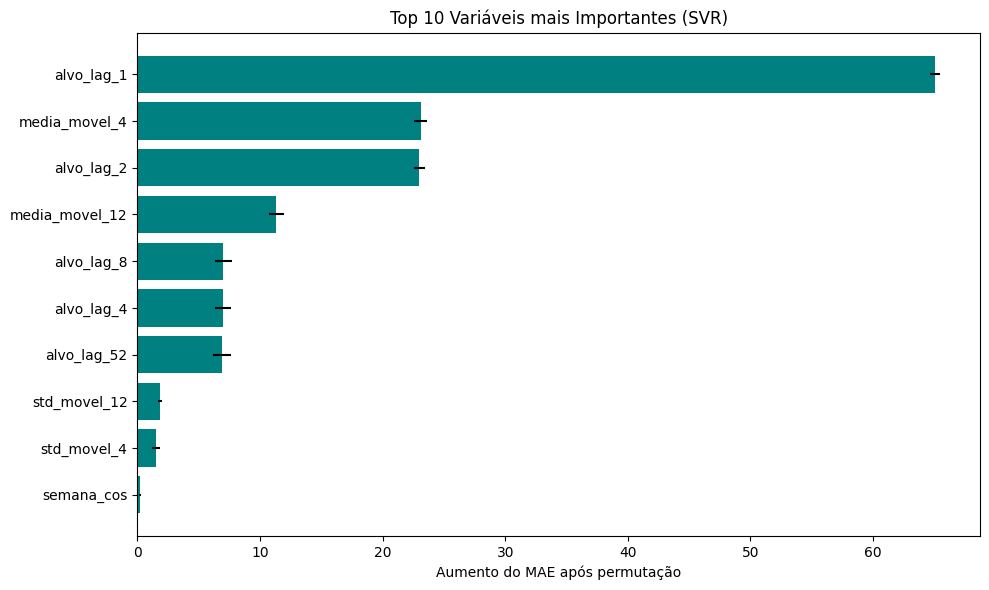


Modelo final (Random Forest) exportado como 'modelo_ouro_final.pkl'
Resultados de previsão exportados como 'previsoes_ouro_teste.csv'


In [22]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# Importância por impureza para Random Forest
importancia_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importancia': rf_model.feature_importances_,
    'Desvio_Padrao': 0.0,
    'Metodo': 'impurity',
}).sort_values(by='Importancia', ascending=False)

print("\n=== TOP 10 FEATURES - RANDOM FOREST (IMPURITY) ===")
print(importancia_rf.head(10).to_string(index=False))

# Permutation importance do SVR no conjunto de teste, conforme a Base 04
svr_permutation = permutation_importance(
    svr_model,
    X_test,
    y_test,
    scoring='neg_mean_absolute_error',
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
importancia_svr = pd.DataFrame({
    'Feature': X_test.columns,
    'Importancia': svr_permutation.importances_mean,
    'Desvio_Padrao': svr_permutation.importances_std,
    'Metodo': 'permutation_mae',
}).sort_values(by='Importancia', ascending=False)

print("\n=== TOP 10 FEATURES - SVR (PERMUTATION IMPORTANCE) ===")
print(importancia_svr.head(10).to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(
    importancia_svr['Feature'].head(10)[::-1],
    importancia_svr['Importancia'].head(10)[::-1],
    xerr=importancia_svr['Desvio_Padrao'].head(10)[::-1],
    color='teal',
)
plt.xlabel('Aumento do MAE após permutação')
plt.title('Top 10 Variáveis mais Importantes (SVR)')
plt.tight_layout()
plt.show()

# Exportação do modelo escolhido pela validação cruzada
joblib.dump(modelo_final, 'modelo_ouro_final.pkl')
print(f"\nModelo final ({nome_modelo_final}) exportado como 'modelo_ouro_final.pkl'")

# Exportação das previsões do conjunto de teste
# y_pred é produzido na seleção feita pela validação cruzada

df_resultados_finais = pd.DataFrame({
    'Data': y_test.index,
    'Real': y_test.values,
    'Previsto': y_pred,
})
df_resultados_finais.to_csv('previsoes_ouro_teste.csv', index=False)
print("Resultados de previsão exportados como 'previsoes_ouro_teste.csv'")